<a href="https://colab.research.google.com/github/greeshmakrishnan00/Machine-Learning/blob/main/Train_Classification_ML(Decision_Tree).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Decision Tree Algorithm - Classification**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read data

In [ ]:
df=pd.read_csv("/content/train.csv")
df.head(4)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2


# Data Cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [ ]:
df.isnull().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# Visualization

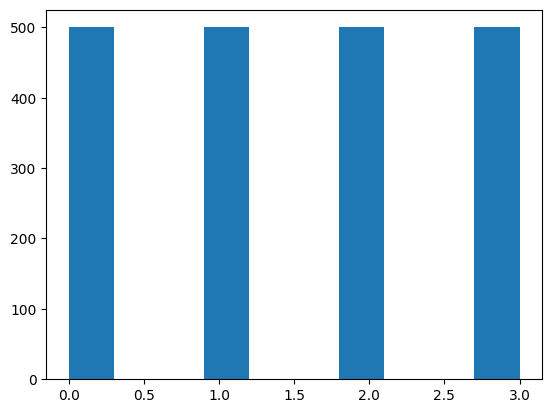

In [ ]:
plt.hist(df["price_range"])
plt.show()

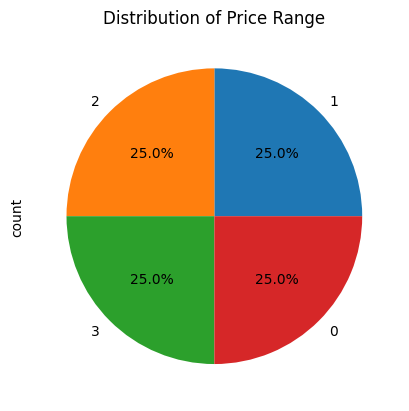

In [ ]:
df["price_range"].value_counts().plot.pie(autopct="%1.1f%%")
plt.title("Distribution of Price Range")
plt.show()

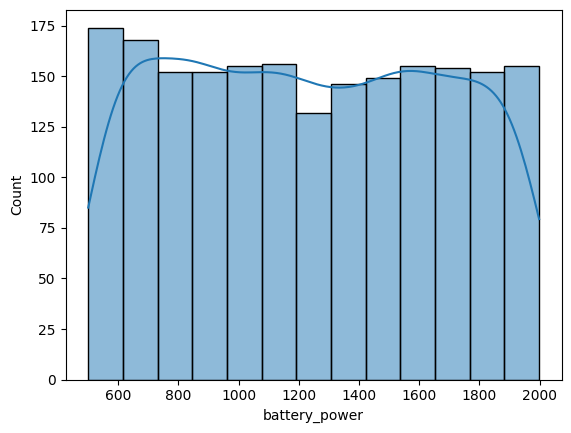

In [ ]:
sns.histplot(df["battery_power"],kde=True)
plt.show()

# Correlation analysis

All the data in numerical form .so we could't perform correlation analysis ( finding unique ,perfom labelencorder,getdumies,replace )

# Corr_Matrix

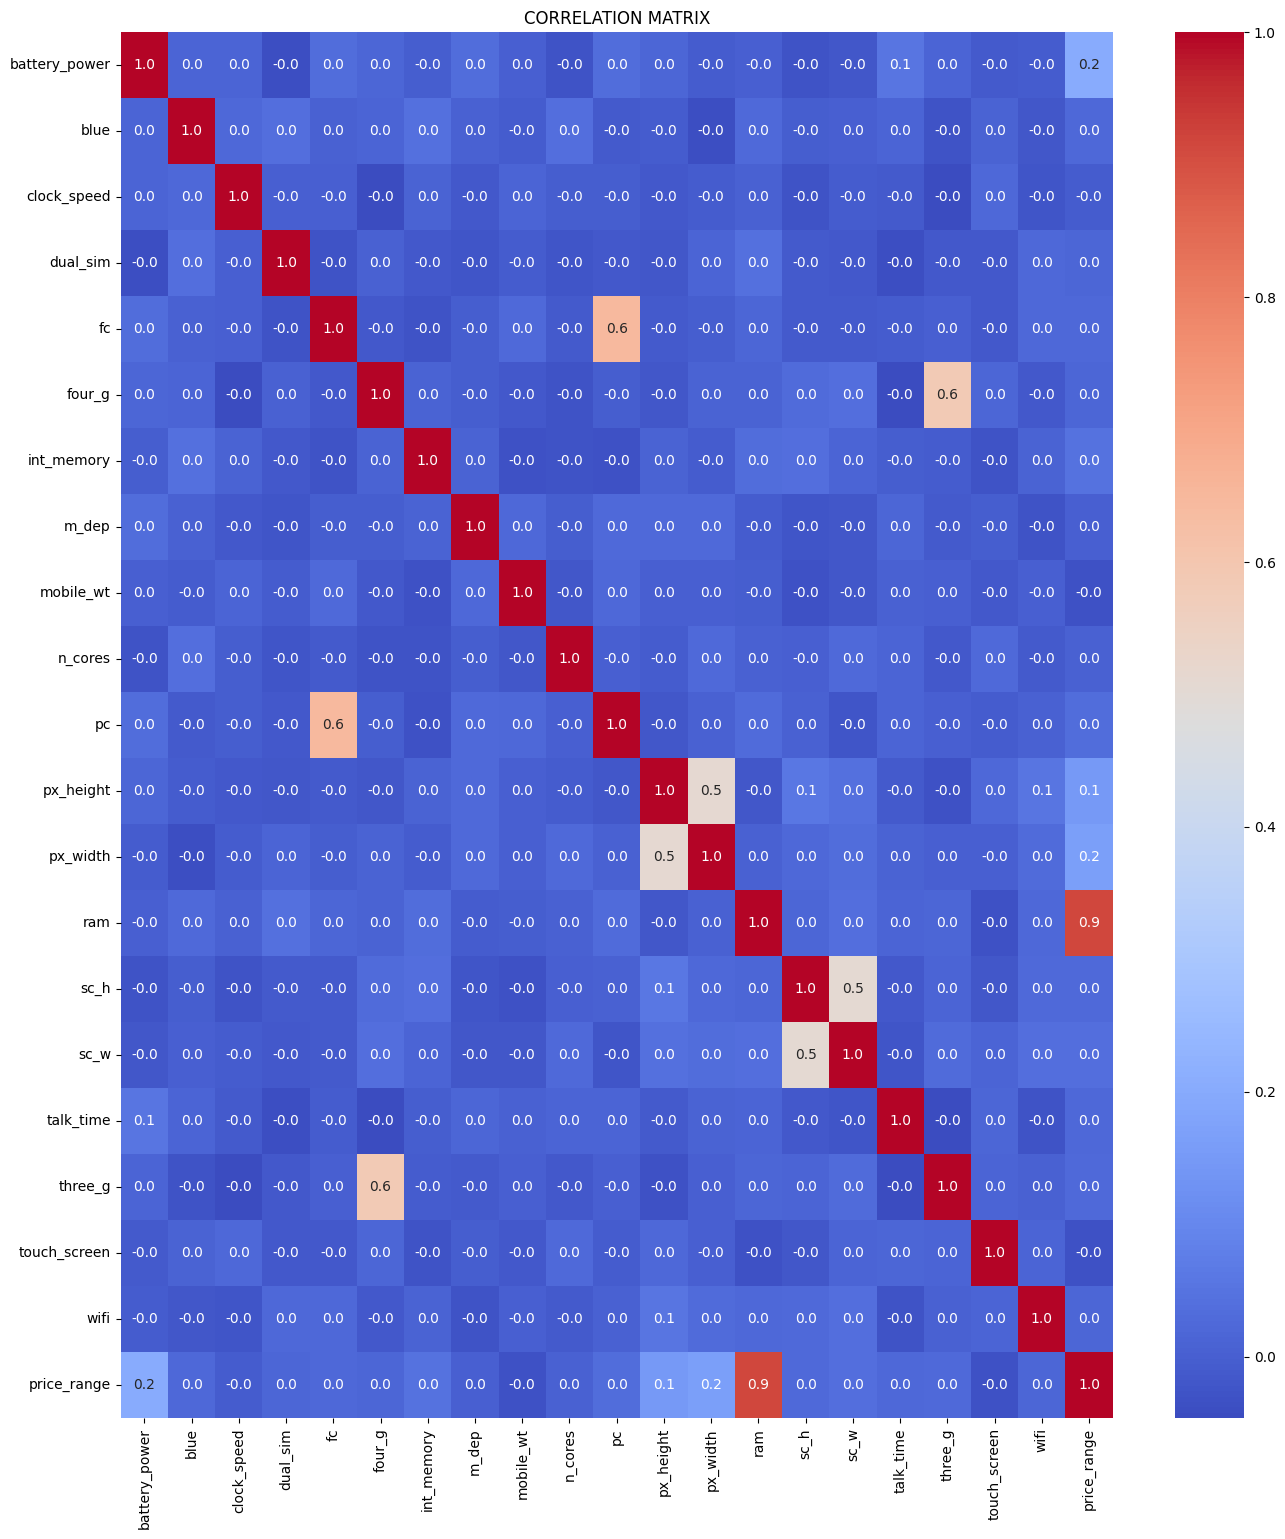

In [ ]:
corr_matrix=df.corr()
plt.figure(figsize=(16,18))
sns.heatmap(corr_matrix,annot=True,fmt="0.1f",cmap="coolwarm")
plt.title("CORRELATION MATRIX")
plt.show()

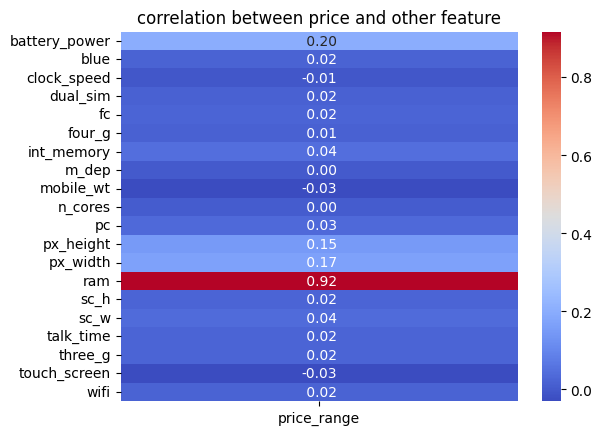

In [ ]:
from pickleshare import stat
status_corr=df.corr()["price_range"]
status_corr=status_corr.drop("price_range")
sns.heatmap(status_corr.to_frame(),annot=True,fmt=" .2f",cmap="coolwarm",cbar=True,annot_kws={'size':10})
plt.title("correlation between price and other feature")
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [ ]:
df.drop(["blue","clock_speed","dual_sim","fc","four_g","m_dep","n_cores","sc_h","talk_time","three_g","wifi"],axis=1,inplace=True)

# Outlier Checking and removing

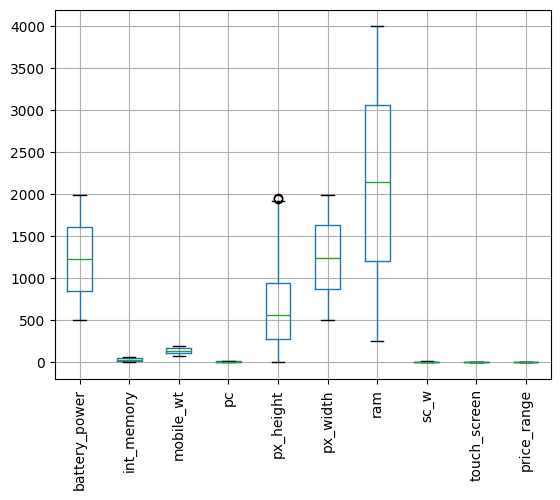

In [ ]:
df.boxplot()
plt.xticks(rotation=90)
plt.show()

In [ ]:
from numpy._core.defchararray import upper
def remove_outliers_iqr(df,exclude_column):
  for col in df.columns:
    if col==exclude_column:
        continue
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lowerbound=Q1-1.5*IQR
    upperbound=Q3+1.5*IQR
    df=df[(df[col]>=lowerbound)&(df[col]<=upperbound)]
  return df
df_cleaned=remove_outliers_iqr(df,exclude_column="price_range")
df=df_cleaned

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1998 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   battery_power  1998 non-null   int64
 1   int_memory     1998 non-null   int64
 2   mobile_wt      1998 non-null   int64
 3   pc             1998 non-null   int64
 4   px_height      1998 non-null   int64
 5   px_width       1998 non-null   int64
 6   ram            1998 non-null   int64
 7   sc_w           1998 non-null   int64
 8   touch_screen   1998 non-null   int64
 9   price_range    1998 non-null   int64
dtypes: int64(10)
memory usage: 171.7 KB


# Data Scaling

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
features=["battery_power","int_memory","mobile_wt","pc","px_height","px_width",'ram',"sc_w","touch_screen"]
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df = pd.DataFrame(scaled_data, columns=features)

In [ ]:
# use logisticRegression because our dataset is classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

x= df[["battery_power","int_memory","mobile_wt","pc","px_height","px_width",'ram',"sc_w","touch_screen"]]
y= df['price_range']  # Target variable

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

# Train a baseline logistic regression model
model=DecisionTreeClassifier()
model.fit(x_train, y_train)

# Predict and evaluate the model
y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.84
